## 신경망 핵심원리

### 자동미분

- 딥러닝의 심장인 기능
- 학습과정에서 수많은 데이터를 통해서 정답에 점점 가까워짐
- 가장 낮은 지점(최소 손실) 찾으려면, `방향`과 `경사`를 수학적으로 계산해야 함 -> **미분**
- 기울기(Gradient) - 데이터들로 판별된 경사도
    - 파라미터(가중치) - 이차 방정식 x^2, y에 포함되는 수
    - 파라미터(편향) - 이차 방정식 마지막 숫자값
- 손실(Loss) - 실제 경사값과 구해진 경사값 사이의 차이
    - 이 손실을 최소화 해야 알맞은 값이 나옴
    - 가중치와 편향을 조정하면서 손실이 최소화 되게 학습

- 경사하강법(Gradient Descent) - 기울기를 조정해서 최소 손실에 가깝게 만드는 과정

#### 자동미분의 역할

- Autograd : 파이토치가 제공하는 자동미분엔진. 사용자가 텐서에서 어떤 연산을 수행하든 그 과정을 모두 기록. 기록을 바탕으로 미분값을 자동 계산
    - requires_grad=True


In [15]:
# PyTorch 시작
import torch

In [16]:
# 텐서 x의 미분값을 계산하도록 설정
x = torch.tensor(2.0, requires_grad=True)

In [17]:
x

tensor(2., requires_grad=True)

In [24]:
# z는 x를 이용한 연산으로 자동미분이 가능해짐
z = x ** 2   # power

In [25]:
z

tensor(4., grad_fn=<PowBackward0>)

In [26]:
y = z * 3  # multi

In [27]:
y

tensor(12., grad_fn=<MulBackward0>)

In [28]:
z.requires_grad

True

In [29]:
y.requires_grad

True

#### 계산 그래프
- Autograd는 계산 그래프(Computational Graph)를 구축해서 작동
- 텐서값과 연산들의 관계를 시각적으로 표현한 것

- y = 3 * z
- `y = 3 * (x ** 2)`
- $ y = 3  x ^ 2 $
- 노드(Node) : 텐서값 x, y, z
- 엣지(Edge) : **2, *3 

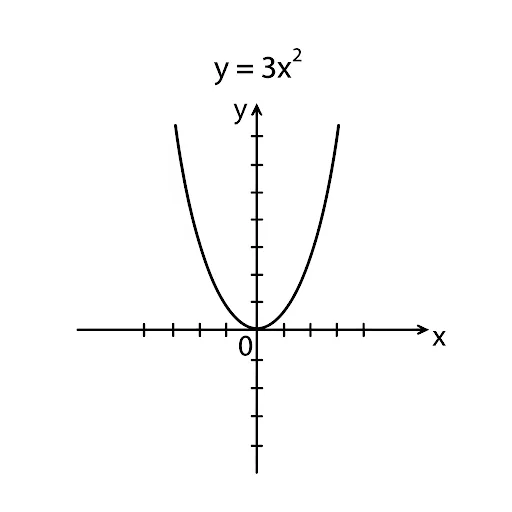


#### 순전파 예
- f(x) = y 구하는 순서. 필요값을 집어넣고 결과를 도출하는 것

```
1. x = 2
2. z = x^2 = 4
3. y = 3 * z = 12
```

#### 역전파(Backward Propagation)
- x가 조금 변한다면 최종결과 y는 얼마나 변할까? 를 알아보는 것 
- 이전 값이 결과에 얼마나 영향을 줬는가? 

```
y -> z -> x
```

$ \frac{dy}{dx} $ 를 구하는 것

1. $ y = 3z $ -> $ \frac{dy}{dz} = 3 $  : z가 1 증가하면 y는 3 증가
2. $ z = x ^ 2 $ -> $ \frac{dz}{dx} = 2x $ : x가 2니까 결과는 4
3. $ \frac{dy}{dx} = \frac{dy}{dz} \times \frac{dz}{dx} $ -> 12

#### 결론

- 이 역전파를 PyTorch가 함수호출로 자동 실행해줌